Model Training 
1: Importing libraries

In [81]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import matplotlib_inline
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso,Ridge
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor 
from xgboost import XGBRegressor
import warnings


Import CSV as pandas dataframe

In [9]:
df=pd.read_csv("D:\mlproject\data\Stud.csv")

In [10]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y variables

In [13]:
X=df.drop(columns=['math score'],axis=1)

In [17]:
X

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [14]:
y=df['math score']

In [18]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64

In [ ]:
#create columns transformer with three types of transformer 
num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

ColumnTransformer:  we use itwhen our data set have mixed faetures like categoriacl and numerical features.
One-Hot Encoding is a technique that converts categorical variables into multiple binary (0/1) columns, where each category is represented by a unique column with a value of 1 indicating its presence.
“StandardScaler = make all features equal in importance by scaling them”
pro tips: so standardscalar: works on numerical features 
One_hot_encoder works on categorical features
numeric_transformer → will scale numeric columns.
oh_transformer → will encode categorical columns.



In [33]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('cat', oh_transformer, cat_features),      # name as string
        ('num', numeric_transformer, num_features)  # name as string
    ]
)

In [34]:
X=preprocessor.fit_transform(X)

point to be noted after fit_transform our df is no more pandas datafram now it has trannsformed into numpy array. because it has benn one hot encoded and scaled.

In [50]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

df.shape

In [48]:
df.shape

(1000, 8)

In [51]:
X.shape

(1000, 19)

Apply train_test_split to convert it into train and test set 

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((700, 19), (300, 19))

Create an evaluate function to give all metrics after model training

In [82]:
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true, predicted))
    r2=r2_score(true,predicted)
    return mae,mse,rmse,r2

Models

In [ ]:
models={
    "linear regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-neighbor regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest Tree":RandomForestRegressor(),
    "XGBregressor": XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(verbose=False),
    "AdaBoostRegressor":AdaBoostRegressor()

}
model_list=[]
r2_list=[]
for i in range(len(list(models))):
   model =list(models.values())[i]
   model.fit(X_train, y_train)
   #make predictions
   y_train_predict=model.predict(X_train)
   y_test_predict=model.predict(X_test)
   #Evaluate train and test data set
   model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_predict)
   model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_predict)

   print(list(models.keys())[i])
   model_list.append(list(models.keys())[i])

   #Model performance for Train set

   print ("Model performance for Training set")
   print(".Root mean Squared error: {:4f}".format(model_train_rmse))
   print(".Mean Absolute error: {:4f}".format(model_train_mae))
   print(".R2 Score: {:4f}".format(model_train_r2))

   #Model Perormance for Test set 

   print("-----------------------------------")

   print("Model performance for test set")
   print(".Root mean Squared error: {:4f}".format(model_test_rmse))
   print(".Mean Absolute error: {:4f}".format(model_test_mae))
   print(".R2 Score: {:4f}".format(model_test_r2))
   r2_list.append(model_test_r2)

   print('='*35)
   print('\n')

linear regression
Model performance for Training set
.Root mean Squared error: 5.248303
.Mean Absolute error: 4.198520
.R2 Score: 0.875131
-----------------------------------
Model performance for tes set
.Root mean Squared error: 5.557571
.Mean Absolute error: 4.418261
.R2 Score: 0.875863


Lasso
Model performance for Training set
.Root mean Squared error: 6.510566
.Mean Absolute error: 5.158226
.R2 Score: 0.807844
-----------------------------------
Model performance for tes set
.Root mean Squared error: 6.870524
.Mean Absolute error: 5.392914
.R2 Score: 0.810281


Ridge
Model performance for Training set
.Root mean Squared error: 5.248655
.Mean Absolute error: 4.197677
.R2 Score: 0.875115
-----------------------------------
Model performance for tes set
.Root mean Squared error: 5.556592
.Mean Absolute error: 4.415506
.R2 Score: 0.875907


K-neighbor regressor
Model performance for Training set
.Root mean Squared error: 5.678445
.Mean Absolute error: 4.503714
.R2 Score: 0.853825
---

Linear Regression

In [85]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_predict=lin_model.predict(X_test)
score=r2_score(y_test,y_predict)*100
print("Accuracy of the model %.2f" % score)

Accuracy of the model 87.59


Plot y_pred and y_test

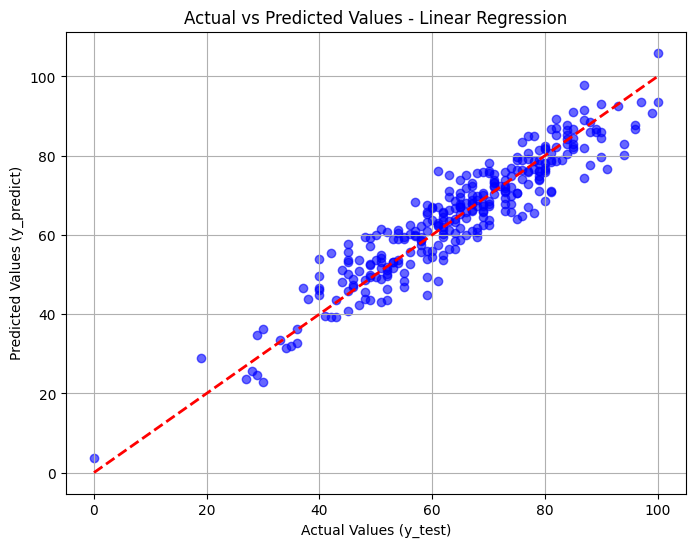

In [86]:

# Scatter plot of true vs predicted values
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_predict, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # perfect prediction line
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_predict)")
plt.title("Actual vs Predicted Values - Linear Regression")
plt.grid(True)
plt.show()

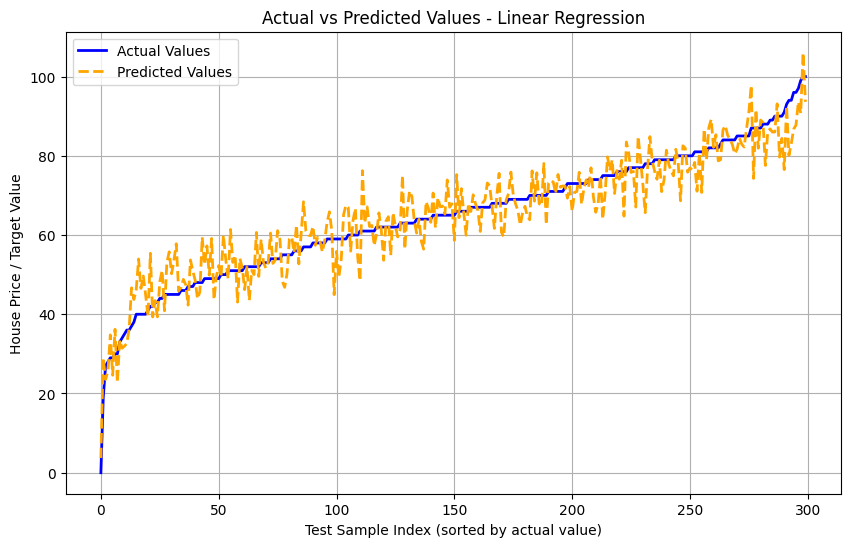

In [87]:
sorted_idx = np.argsort(y_test)

plt.figure(figsize=(10,6))
plt.plot(np.array(y_test)[sorted_idx], label='Actual Values', color='blue', linewidth=2)
plt.plot(np.array(y_predict)[sorted_idx], label='Predicted Values', color='orange', linewidth=2, linestyle='--')
plt.xlabel("Test Sample Index (sorted by actual value)")
plt.ylabel("House Price / Target Value")
plt.title("Actual vs Predicted Values - Linear Regression")
plt.legend()
plt.grid(True)
plt.show()